# Introduction to Data Analysis

Amal Bumbia 

The tools we need to use are primarily Matplotlib and Pandas. There are other packages that can be useful like Scipy, and certain examples will reference them. 

Topics Covered in this Notebook:
    
    - Curve Fitting (Gaussian, Linear, Sinusoidal, Hyperbolic Tangent)
    
    - Creating different plots (line, histograms, 3D, overlays) and using Pandas
    
    - Image Processing
    
    - Finding Peaks in a Spectrum

General tips that you should absolutely follow are:

    - Use variable names that make sense and make it obvious what you are referring to without being too long

    - Always comment your code so people looking at it will know what you're trying to do

    - Generalizing code snippets with a particular function into a Python function is a VERY good idea since it helps you be more efficient and keep your environment clean and organized. It also makes it easy to modify your code for different applications and share it

## Imports 

In [25]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
import plotly.graph_objects as go
%matplotlib inline 
import pandas
import pandas as pd
from scipy.optimize import curve_fit
from __future__ import division, unicode_literals, print_function  # for compatibility with Python 2 and 3

import matplotlib as mpl
from pandas import DataFrame, Series  # for convenience

# imports for a very specific example - don't worry about these
import pims
import trackpy as tp
from scipy.signal import find_peaks
from mpl_toolkits.mplot3d import Axes3D

# Creating Plots and Using Pandas

In most cases, we visualize the results of our data in terms of plots. These are pretty easy to make. I want to show you some ways to overlay plots and make 3D plots as well as histograms. However, the more important takeaway from this section is that how to process different data files. Later, we will process an image using trackpy which is a very specific python package. You can largely get away with not having to do something like that, but it depends on what format your data is in and what you wish to extract from it. Pandas is super useful since it extracts your data more efficiently than using various python loops and lists. Pandas can help you extract your data into either one or multiple data frame objects that you can easily mainpulate via built in commands. This is especially helpful when your data file has weird deliminators or spacings. 

## Example  - Sample Doping Dependence

This data file is an example of an annoying layout. Here, you have enough data for six plots where the columns are split using either a space or a tab depending on whether you are moving onto a new dataset. Using a for loop would be wildly annoying to deal with in this case. Pandas is awesome.

In [27]:
# Sometimes it helps to manually clean up a dataset --- don't do anything intense 
# In my experience I've only ever needed to delete descriptor lines from the file that wouldn't be processed right.

def tex_to_dataframe(tex_file):
    # Read the TeX file
    with open(tex_file, 'r') as f:
        tex_content = f.readlines()

    # Initialize an empty list to store rows
    table_data = []

    # Iterate over each line in the TeX file
    for line in tex_content:
        # Split the line by tabs and spaces
        cells = line.strip().split()

        # Append the cells to the table data
        table_data.append(cells)

    # Create a DataFrame from the table data
    df = pd.DataFrame(table_data)

    # Delete the first row
    df = df.iloc[1:]

    return df

# Calling the function
tex_file = 'doping_dependence_cleaned.txt'
df = tex_to_dataframe(tex_file)
print(df)

            0            1          2            3          4            5   \
1    1549.1637  0.009371494  1549.1637  0.005874357  1549.1637  0.002980551   
2    1550.1858  0.004883199  1550.1858  0.001614367  1550.1858  0.002381303   
3     1551.208  0.005324862   1551.208  0.001430638   1551.208  0.001829989   
4    1552.2302  0.006555411  1552.2302  0.007689247  1552.2302  0.007416266   
5    1553.2524  0.002027529  1553.2524  0.001932224  1553.2524  0.006275574   
..         ...          ...        ...          ...        ...          ...   
114   1664.669  0.001846564   1664.669  0.007033635   1664.669  0.006989113   
115  1665.6911  0.005234779  1665.6911  0.004345431  1665.6911  0.007455104   
116  1666.7133  0.007056339  1666.7133  0.005297053  1666.7133  0.004648924   
117  1667.7355  0.006809591  1667.7355  0.003235523  1667.7355  0.007235475   
118  1668.7576  0.008539583  1668.7576  0.002368756  1668.7576  0.003461995   

            6            7          8            9 

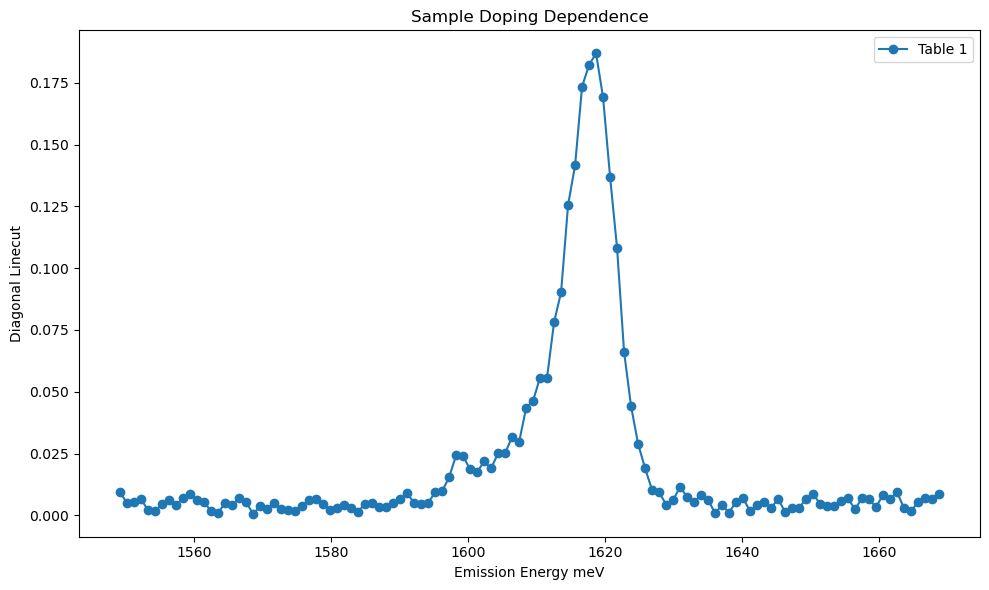

Table 1:
             0            1
1    1549.1637  0.009371494
2    1550.1858  0.004883199
3     1551.208  0.005324862
4    1552.2302  0.006555411
5    1553.2524  0.002027529
..         ...          ...
114   1664.669  0.001846564
115  1665.6911  0.005234779
116  1666.7133  0.007056339
117  1667.7355  0.006809591
118  1668.7576  0.008539583

[118 rows x 2 columns]



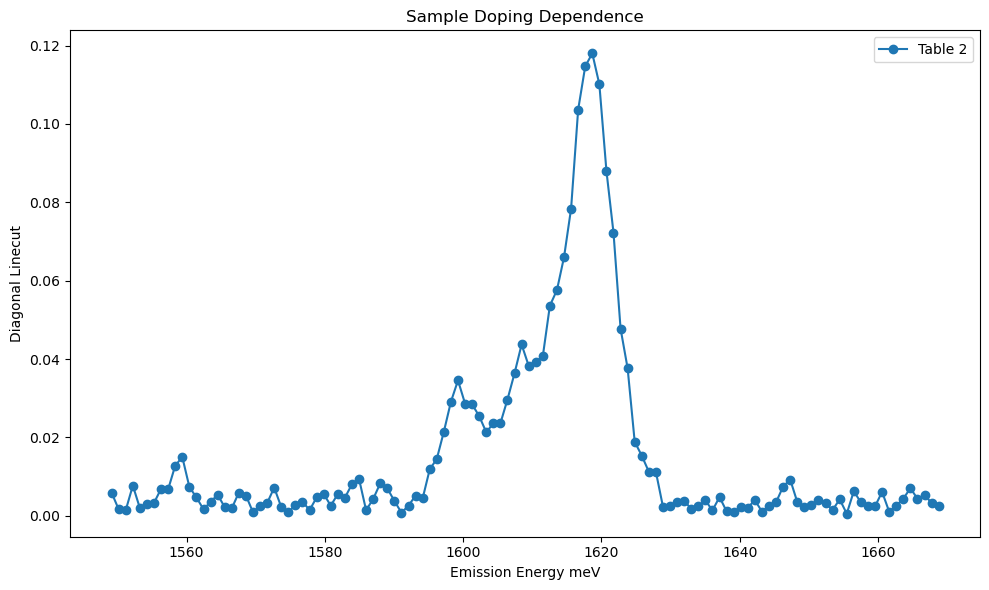

Table 2:
             2            3
1    1549.1637  0.005874357
2    1550.1858  0.001614367
3     1551.208  0.001430638
4    1552.2302  0.007689247
5    1553.2524  0.001932224
..         ...          ...
114   1664.669  0.007033635
115  1665.6911  0.004345431
116  1666.7133  0.005297053
117  1667.7355  0.003235523
118  1668.7576  0.002368756

[118 rows x 2 columns]



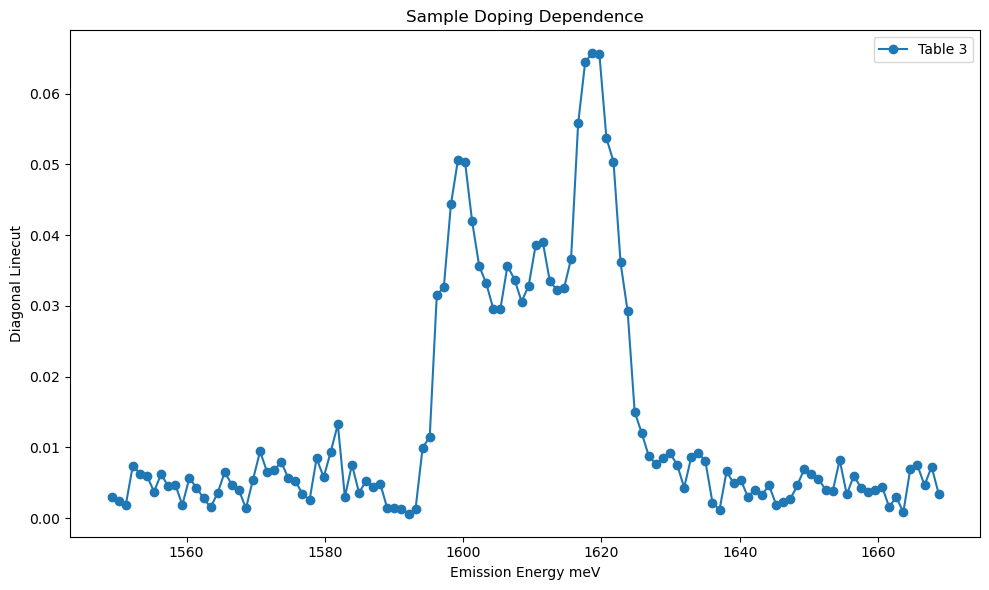

Table 3:
             4            5
1    1549.1637  0.002980551
2    1550.1858  0.002381303
3     1551.208  0.001829989
4    1552.2302  0.007416266
5    1553.2524  0.006275574
..         ...          ...
114   1664.669  0.006989113
115  1665.6911  0.007455104
116  1666.7133  0.004648924
117  1667.7355  0.007235475
118  1668.7576  0.003461995

[118 rows x 2 columns]



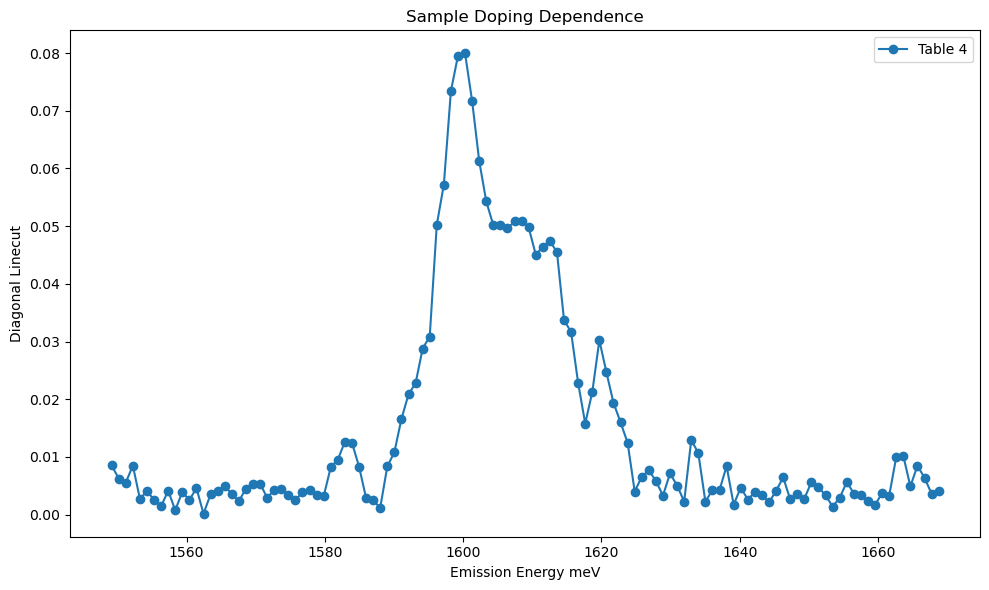

Table 4:
             6            7
1    1549.1637  0.008545977
2    1550.1858  0.006251325
3     1551.208  0.005538262
4    1552.2302  0.008498243
5    1553.2524  0.002735309
..         ...          ...
114   1664.669   0.00488945
115  1665.6911  0.008472932
116  1666.7133  0.006396757
117  1667.7355  0.003610607
118  1668.7576  0.004065574

[118 rows x 2 columns]



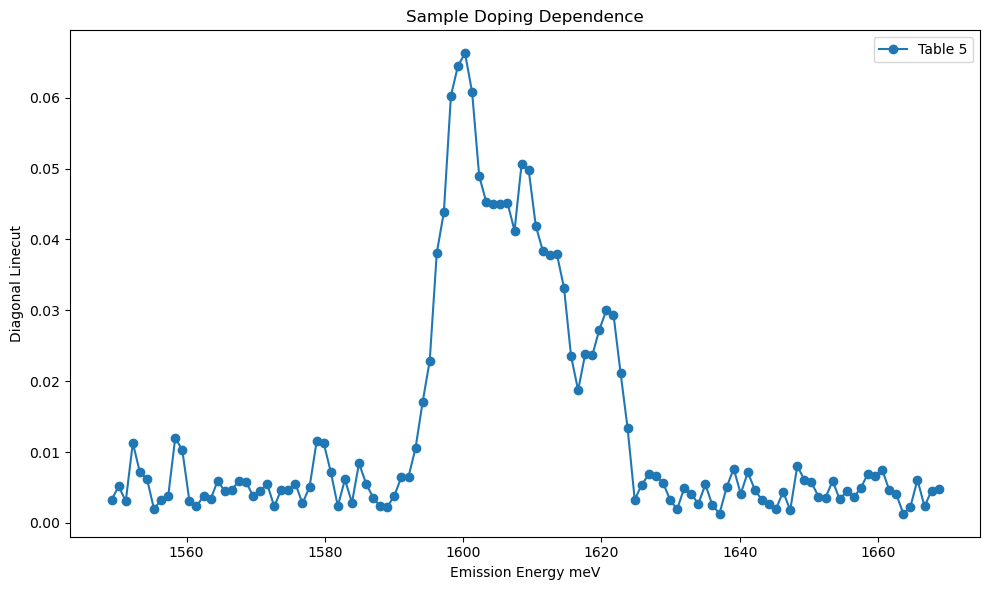

Table 5:
             8            9
1    1549.1637   0.00329881
2    1550.1858  0.005170625
3     1551.208  0.003073159
4    1552.2302     0.011301
5    1553.2524  0.007135906
..         ...          ...
114   1664.669  0.002255725
115  1665.6911  0.006090988
116  1666.7133  0.002347735
117  1667.7355  0.004566601
118  1668.7576  0.004753634

[118 rows x 2 columns]



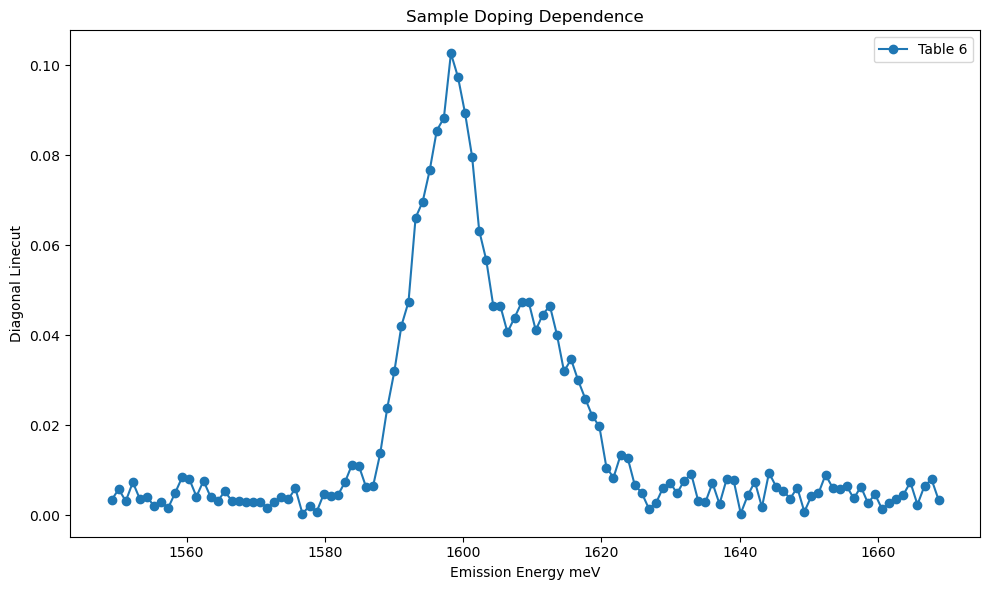

Table 6:
            10           11
1    1549.1637  0.003429852
2    1550.1858  0.005855725
3     1551.208  0.003174465
4    1552.2302  0.007370212
5    1553.2524  0.003624418
..         ...          ...
114   1664.669  0.007383612
115  1665.6911  0.002399616
116  1666.7133   0.00657958
117  1667.7355  0.007988587
118  1668.7576   0.00343219

[118 rows x 2 columns]



In [28]:
def split_table(df):
    # I wanted to make six plots with this data frame, so I split it into six tables for easier access
    num_columns = df.shape[1]

    # Check if the number of columns is divisible by 2
    if num_columns % 2 != 0:
        raise ValueError("Number of columns must be divisible by 2")

    # Initialize a list to store the split DataFrames
    split_dfs = []

    # Split the DataFrame into multiple DataFrames with 2 columns each
    for i in range(0, num_columns, 2):
        split_df = df.iloc[:, i:i+2]
        split_dfs.append(split_df)

    return split_dfs


split_dfs = split_table(df) # Call the function to split the dataframe into the tables
fig = go.Figure() # Initialize figure 

# Output each split DataFrame
for i, split_df in enumerate(split_dfs):
    x_values = split_df.iloc[:, 0].astype(float)  # Extract the first column as x-values
    y_values = split_df.iloc[:, 1].astype(float) # Extract the second column as y-values
    plt.figure(figsize=(10, 6))  # Adjust size as needed
    
    # Plot the data from the split DataFrame
    plt.plot(x_values, y_values, marker='o', linestyle='-', label=f'Table {i+1}')
    
    plt.xlabel('Emission Energy meV')  
    plt.ylabel('Diagonal Linecut')  
    plt.title('Sample Doping Dependence')  
    plt.grid(False)  
    plt.legend()
    plt.tight_layout()
    plt.show()
    # Create a Plotly trace --- this allows us to create an interactive plot overlay
    trace = go.Scatter(x=x_values, y=y_values, mode='lines', name=f'Table {i+1}')
    fig.add_trace(trace)
    print(f"Table {i+1}:")
    print(split_df)
    print()
fig.show()

## Example - Processing and Plotting Photoluminescence Data

Due to the sheer length and number of relevant files involved, I will open these notebooks as other examples if we have time. For now, here are the functions I generalized to facilitate the analysis process just so you can see. 

In [ ]:
def picture(image_path):
    # opening the file as an image and displaying it using plotly
    with open(image_path, 'rb') as f:
        image_data = f.read()
    image = mpimg.imread(image_path)
    plt.imshow(image)
    plt.axis('off')
    plt.show()

In [ ]:
def plotting(file, point):
    # opening a file of raw data that does not correspond to an image type
    with open(file, 'r') as file:
        lines = file.readlines()

    # set range --- I'm trying to plot the wavelength spectra corresponding to a specific point that was measured. 
    # the file contained the wavelengths and the corresponding intensities at those wavelengths as they were applied to the
    # point during a PL measurement
    # I am only concerned with plotting a specific range of wavelengths
    low_wl = 600.0 # nm
    high_wl = 680.0 # nm

    # x and y values - initialize lists storing the x and y values of my plot (wavelength vs intensity)
    x = []
    y = []
    for line in lines: # reading lines in file, sorting them based on my range restrictions so only 
        # the relevant data is sent to my x and y lists
        parts = line.split(',')
        if float(parts[0]) <= low_wl:
            pass
        elif float(parts[0]) >= high_wl:
            pass
        else:
            x.append(float(parts[0])) 
            y.append(float(parts[2]))  

    # Plot
    plt.plot(x, y)
    plt.xlabel('wavelength')  
    plt.ylabel(' ')  
    plt.title(point +' RT mAgNC')  
    plt.grid(False)  
    plt.show()
    # Create a Plotly trace
    trace = go.Scatter(x=x, y=y, mode='lines', name=point + ' RT mAgNC')

    return trace

In [ ]:
def hyperspectral_spatial_image(title,files,folder,calibration_file,xsteps,ysteps,
                                x_step_size,y_step_size,rel_spec_ind,x_crop,y_crop):
    # Generating the PL hyperspectral spatial image using PL files --- a bit more instensive
    # Find and sort all files by number:
    files = [file for file in folder.glob(file_prefix+'*')] # find all relevant files
    files = sorted(files,
                   key=lambda x:float(x.name.replace(file_prefix,'').replace(file_suffix,''))) # sort files by index number

    # Calculate wl from calibration file
    wl = 1240/np.loadtxt(folder/calibration_file)[:,0]
    display(wl)

    # Load all data files into single array
    data_vector = [np.loadtxt(file) for file in files]

    # Rearrange data into spatial map according to preset xsteps and ysteps
    data = np.array(data_vector)
    data=data.reshape(xsteps,ysteps,-1)
    data = data[x_crop[0]: x_crop[1], y_crop[0]:y_crop[1]]
    x_um = np.arange(data.shape[0])*x_step_size
    y_um = np.arange(data.shape[1])*y_step_size

    int_data = data[:,:,rel_spec_ind[0]:rel_spec_ind[1]].sum(axis=2)
    plt.pcolor(int_data,cmap='gray')
    plt.colorbar() 

    # Create Data array in order to define axes 
    data_ds = xr.DataArray(
        data=data,
        coords=dict(

            x=x_um,

            y=y_um,

            wl=wl.round(1),
        ),
        )

    return wl,data_ds,x_um,y_um,data


In [ ]:
def animated_figure(wl,data_ds,title):
    # using the hyperspectral spatial image data to create an animation of wavelengths applied over time
    fig = px.imshow(data_ds, animation_frame='wl',
                    zmin=300, zmax=1500,
                    aspect='equal',
                    color_continuous_scale='gray',
                    labels={'x': 'X (um)', 'y': 'Y(um)', 'color': 'cps'},
                    origin='lower',
                   )
    fig.write_html(title + "hyperspectral_spatial_image.html") # this is a way to save the output file externally
    fig.show()

In [ ]:

def find_peaks(rel_spec_ind,data):
    # wanted to find the intensity peaks in the hyperspectral spatial image
    # this function is a great example of how things can get convoluted if you don't name variables 
    # intuitively and use sufficient comments to describe what's going on 
    # I lowkey just played around with it since it was written before I converted it to a function
    # and I had to use trial and error to make it work the way I wanted because it was confusing to parse without comments
    fig, ax = plt.subplots(1,2)
    rel_data = data[:,:,rel_spec_ind[0]:rel_spec_ind[1]]
    rel_data = ndimage.gaussian_filter(rel_data, sigma=[0.01,0.01,10])
​
    pts = []
​
    for i in range(rel_data.shape[2]):
        if np.mod(i,10)==0:
            im = rel_data[:,:, i]
            blobs_doh = blob_dog(im, max_sigma=1, threshold_rel=0.5)
            plt.subplot(1,2,1)
            plt.imshow(im)
            plt.subplot(1,2,2)
            plt.imshow(im)
            for blob in blobs_doh:
                y, x, r = blob
                c = plt.Circle((x, y), r, color='red', linewidth=2, fill=False)
                plt.gca().add_patch(c)
                pts.append([y,x])
​
            plt.title(wl[rel_spec_ind[0]:rel_spec_ind[1]][i].round(2))
            plt.show()
​
    unique_pts = np.unique((np.array(pts)).round(), axis=0)
    plt.imshow(data[:,:,rel_spec_ind[0]:rel_spec_ind[1]].sum(axis=2))
    plt.gca().invert_yaxis()
    plt.scatter(unique_pts[:,1],unique_pts[:,0],marker='*',c='r')

    background_spectra = rel_data.sum(axis=0).sum(axis=0)
    # remove peak spectra
    for pt in unique_pts.round().astype(int):
        background_spectra-= rel_data[pt[0], pt[1]]
    # normalize background
    n_points = rel_data.shape[0]*rel_data.shape[1] - len(unique_pts)
    background_spectra /= n_points
​
    from scipy.cluster.hierarchy import fclusterdata
    cluster_pred = fclusterdata(unique_pts, 1, criterion='distance')
    
    return unique_pts,cluster_pred,background_spectra

In [ ]:
def label_points(unique_pts,y_um,x_um,rel_spec_ind,title):
    # this function is easier to understand since it takes the unique points corresponding to the peaks in 
    # the measurement and labels them iteratively
    unique_centroids = to_codebook(unique_pts,cluster_pred).round().astype(int)
    plt.pcolor(y_um,
               x_um,
               data[:,:,rel_spec_ind[0]:rel_spec_ind[1]].sum(axis=2),
               cmap='gray'
              )
    plt.xlabel('X (um)')
    plt.ylabel('Y (um)')

    plt.scatter(unique_centroids[:,1]*x_step_size,unique_centroids[:,0]*y_step_size,marker='*',c='b')
    for i in range(len(unique_centroids)):
        plt.annotate(i+1, (unique_centroids[i,1]*x_step_size,unique_centroids[i,0]*y_step_size), c='b')

    plt.savefig(title + 'spatial_map.png')
    return unique_centroids

In [ ]:
def make_plots(unique_centroids,title,data,wl,background_spectra):
    # this is a function that allows me to plot the wavelength spectra of each unique point with respect to intensity
    fig=go.Figure()

    for i, pt in enumerate(unique_centroids):
        # I iterate through the points and extract the data I need for the plots
        spectrum = data[pt[0]-2:pt[0]+2, pt[1]-2:pt[1]+2].mean(axis=0).mean(axis=0)
        wavelength = wl[rel_spec_ind[0]:rel_spec_ind[1]]
        spectrum = spectrum[:len(wavelength)]
        #wavelength = wavelength[:len(spectrum)]
        #print(f"Spectrum length: {len(spectrum)}, Wavelength length: {len(wavelength)}")
        fig.add_trace(go.Scatter(x= wl, y =data[pt[0]-2:pt[0]+2,
                                                pt[1]-2:pt[1]+2].mean(axis=0).mean(axis=0),
                                name=i+1
                                ))
        # Plot spectrum
        plt.figure()
        plt.plot(wavelength, spectrum)
        plt.xlabel('Wavelength (nm)')
        plt.ylabel('')
        plt.title(f'{title} {i+1}')
        plt.grid(False)
        plt.show()
    # this helps me overlay the individual plots into one interactive plot
    fig.add_trace(go.Scatter(x=wl[rel_spec_ind[0]:rel_spec_ind[1]], y=background_spectra, name='bkg'))
    fig.write_html(title + 'spectra_plots.html')
    fig.show()

## Example - Histogram

Text(0.5, 1.0, 'Histogram of X-Coordinate of Particle 1')

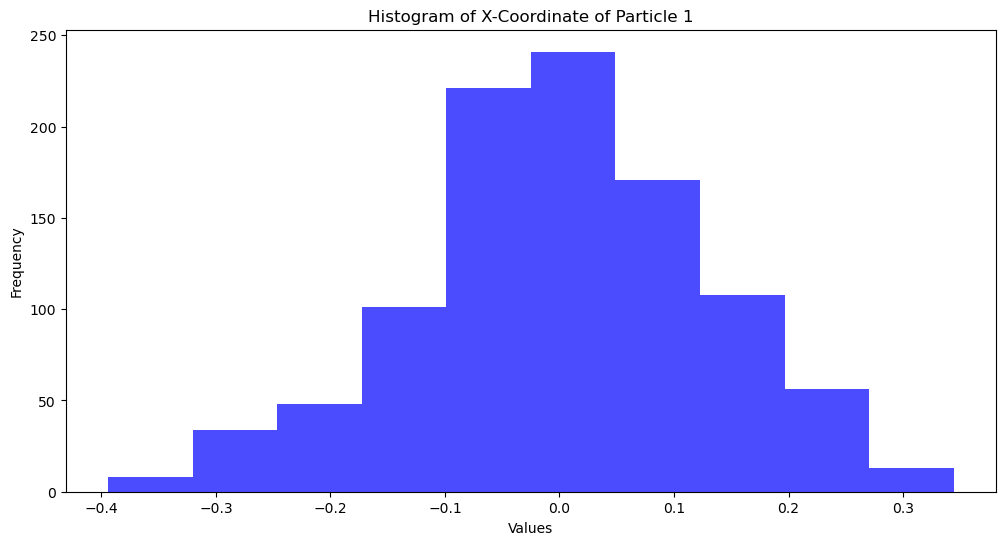

In [7]:
def read_file_with_pandas(file):
    # Read the file using pandas
    df = pd.read_csv(file, delim_whitespace=True, header=None)
    return df

file = 'SampleData_Summer2024.dat'
df = read_file_with_pandas(file)

# Column 1 refers to the x-coordinate of particle 1 and column 4 refers to the x-coordinate of particle 2
# The indices are different since pandas/python indexes starting with zero
columns_to_plot = df.iloc[:, [1, 4]]
    
# Create a figure with two subplots
fig, axs = plt.subplots(1, figsize=(12, 6))

# Plot histogram for column 1 (Particle 1 x-coordinate)
axs.hist(columns_to_plot.iloc[:, 0], bins=10, color='blue', alpha=0.7)
axs.set_xlabel('Values')
axs.set_ylabel('Frequency')
axs.set_title('Histogram of X-Coordinate of Particle 1')

## Example - 3D Plot

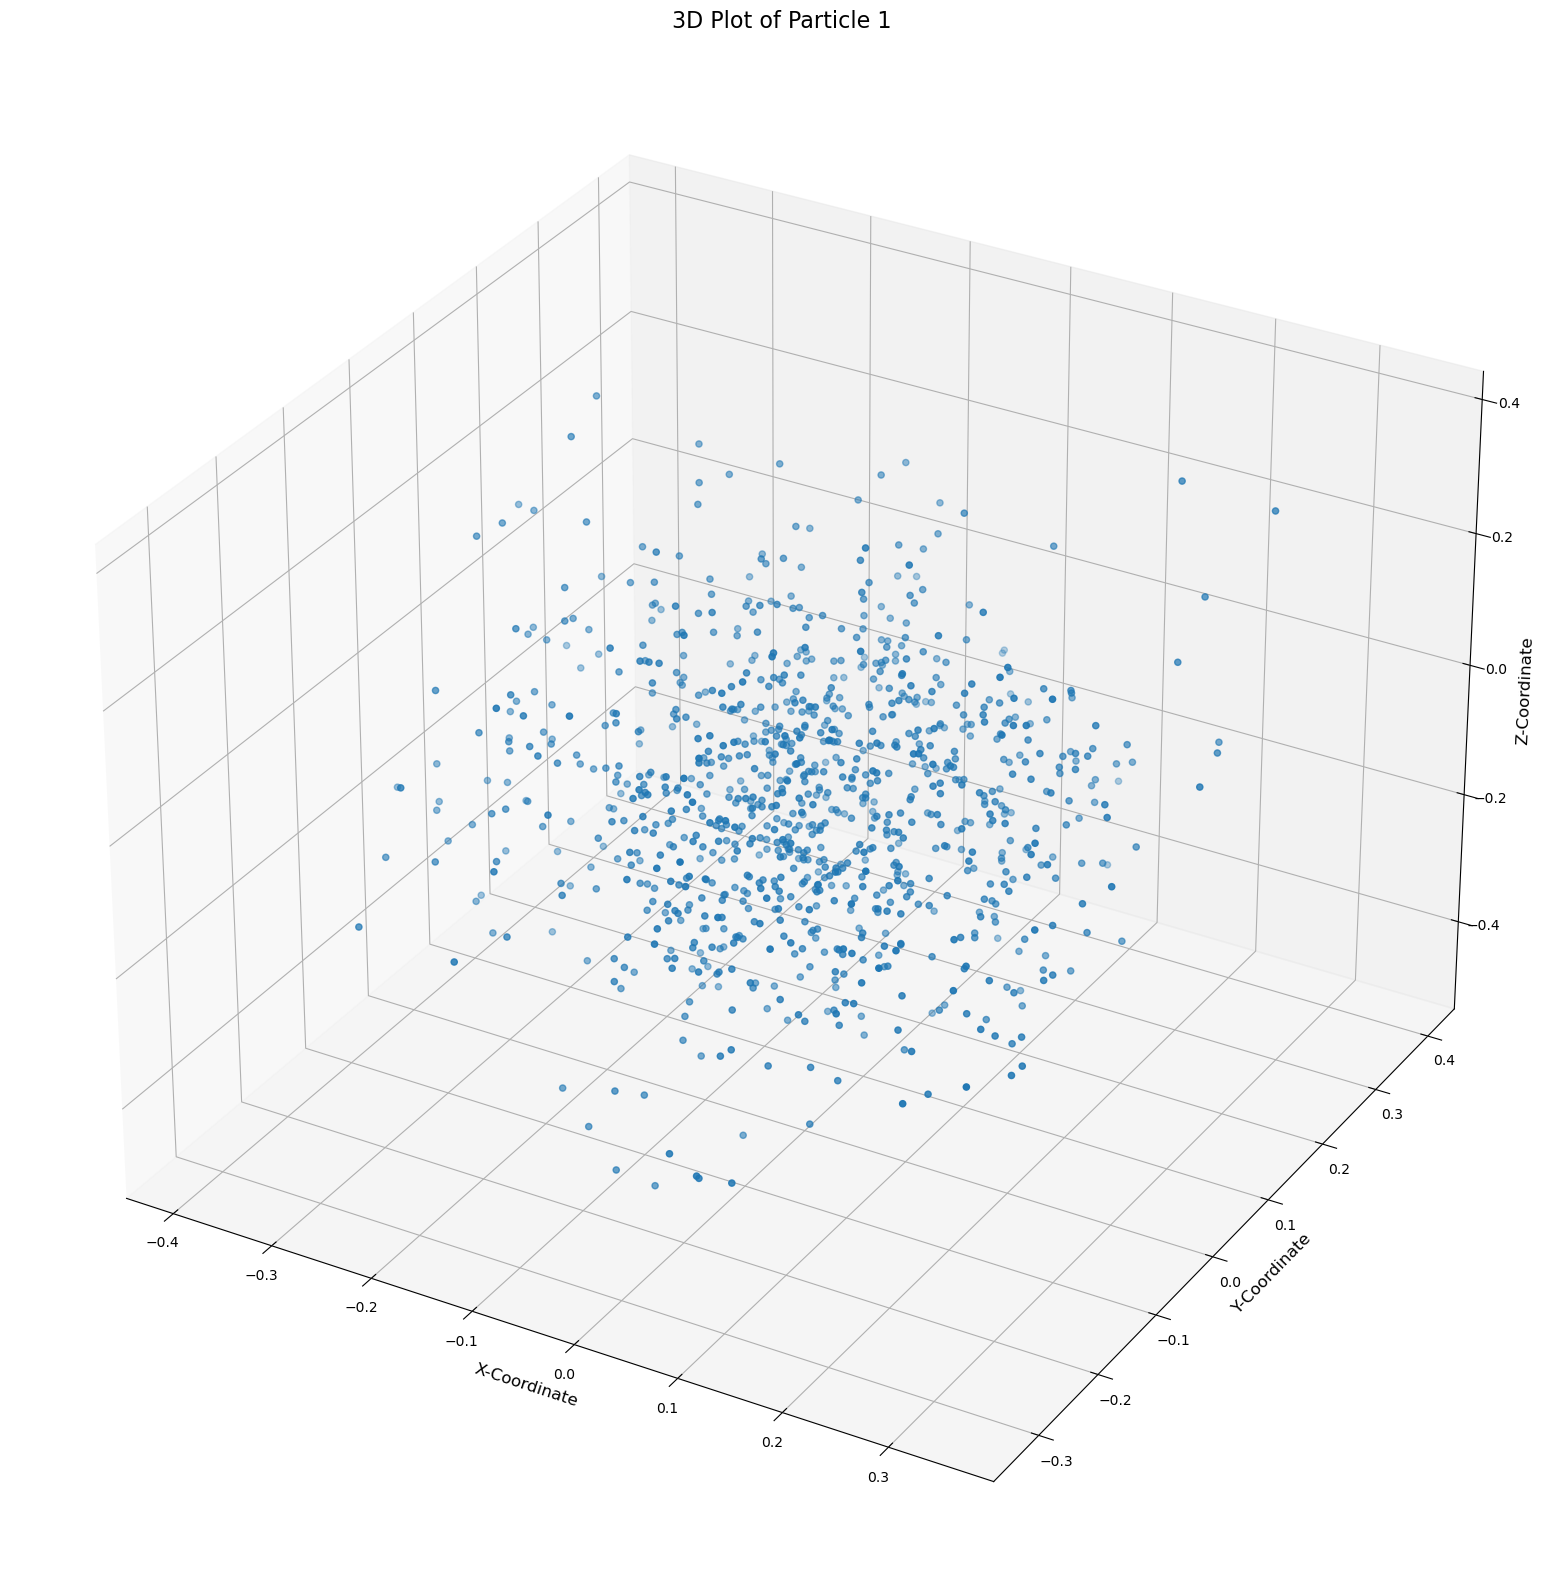

In [8]:
# Making a 3D plot for particle 1
columns_to_plot = df.iloc[:, [1, 2, 3]]
# Create a 3D scatter plot
fig = plt.figure(figsize=(20, 16))
ax = fig.add_subplot(111, projection='3d')

# Extract x, y, z coordinates
x = columns_to_plot.iloc[:, 0]
y = columns_to_plot.iloc[:, 1]
z = columns_to_plot.iloc[:, 2]

# Plot the points
ax.scatter(x, y, z, marker='o')

ax.set_xlabel('X-Coordinate', fontsize=12)
ax.set_ylabel('Y-Coordinate', fontsize=12)
ax.set_zlabel('Z-Coordinate', fontsize=12)
ax.set_title('3D Plot of Particle 1', fontsize=16)
plt.grid(False)  
plt.tight_layout()
plt.show()

# Curve Fitting

Say you have some collection of data that you were able to plot up nicely. How can you break it down and extract certain parameters and errors? This is where curve fitting is useful. Based on the pattern it appears your data might follow, you can choose a function which plots similarly and fit it to your data. You do this by altering the parameters of this model function to "best fit" your data.

Here's an outline of how this process works supposing you have x axis and y axis data.

In [ ]:
# Define a model function 
# Use the scipy curve_fit function after making an "initial guess" of the parameters

# Let popt be the variable denoting optimal parameters for the model function as applied to your data

# Let pcov be the variable denoting the covariance matrix of the parameters -
# the diagonals refer to the covariance of the actual parameters; the off-diagonals refer to covariance between parameters -
# How sensitive is your model function to a change in any particular parameter? 
# Would changing a parameter result in a better fit?

# Obtain popt, pcov = curve_fit(model function, x data, y data, initial_guess=[parameter1,parameter2,parameter3])
# popt can be decomposed into parameter1_opt, parameter2_opt, parameter3_opt
# pcov will appear as the aforementioned matrix

# apply the fit to your data; create a corresponding x and y axis for it
# x_model = np.linspace(min(x_data), max(y_data), steps)
# y_model = modelfunction(x_model, parameter1_opt, parameter2_opt, parameter3_opt)

# Now you can plot the fit and the data on the same plot!

# You can obtain errors by applying np.sqrt(np.diag(pcov)) 
# which is taking the diagonals of the pcov matrix and square-rooting them
# Then, you can plot error-bars

## Example - Basic Gaussian Curve Fit

This example is from https://www.geeksforgeeks.org/python-gaussian-fit/

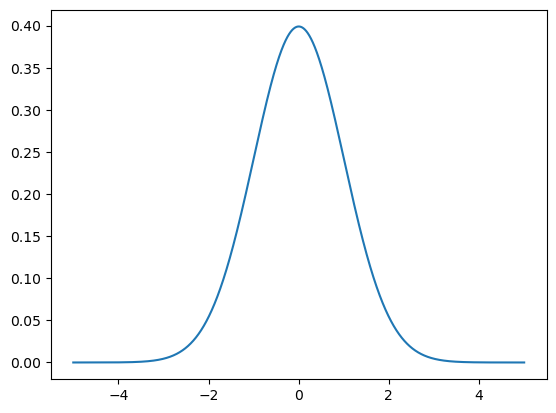

In [9]:
import numpy as np 
import scipy as sp 
from scipy import stats 
import matplotlib.pyplot as plt  
  
# generate the data and plot it for an ideal normal curve 
  
# x-axis for the plot 
x_data = np.arange(-5, 5, 0.001) 
  
# y-axis as the gaussian 
y_data = stats.norm.pdf(x_data, 0, 1) 
  
# plot data 
plt.plot(x_data, y_data)

In [10]:
# Define the Gaussian function 
def gauss(x, H, A, x0, sigma): 
    return H + A * np.exp(-(x - x0) ** 2 / (2 * sigma ** 2))

C:\Users\17135\AppData\Local\Temp\ipykernel_33848\1642420417.py:17: RuntimeWarning:

overflow encountered in exp



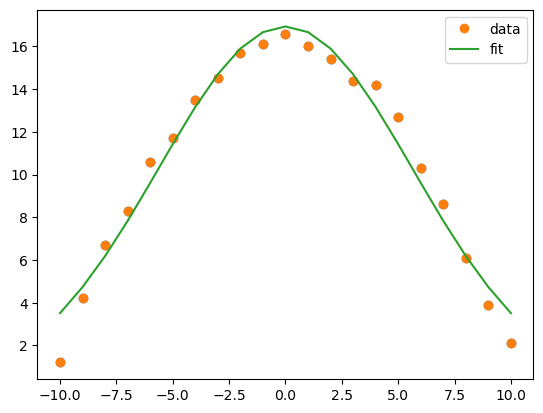

In [11]:
from __future__ import print_function 
import numpy as np 
import matplotlib.pyplot as plt 
from scipy.optimize import curve_fit 
xdata = [ -10.0, -9.0, -8.0, -7.0, -6.0, -5.0, -4.0, -3.0, -2.0, -1.0, 0.0, 
         1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0] 
ydata = [1.2, 4.2, 6.7, 8.3, 10.6, 11.7, 13.5, 14.5, 15.7, 16.1, 16.6, 16.0, 
         15.4, 14.4, 14.2, 12.7, 10.3, 8.6, 6.1, 3.9, 2.1] 
  
# Recast xdata and ydata into numpy arrays so we can use their handy features 
xdata = np.asarray(xdata) 
ydata = np.asarray(ydata) 
plt.plot(xdata, ydata, 'o') 
  
# Define the Gaussian function 
def Gauss(x, A, B): 
    y = A*np.exp(-1*B*x**2) 
    return y 
parameters, covariance = curve_fit(Gauss, xdata, ydata) 
  
fit_A = parameters[0] 
fit_B = parameters[1] 
  
fit_y = Gauss(xdata, fit_A, fit_B) 
plt.plot(xdata, ydata, 'o', label='data') 
plt.plot(xdata, fit_y, '-', label='fit') 
plt.legend()

[ 1.08331847  5.16244398 -1.87096017]


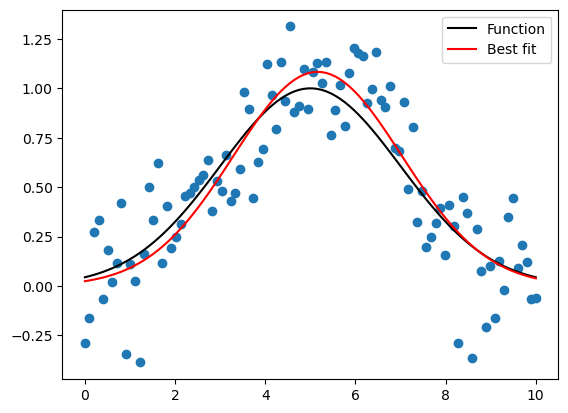

In [12]:
import numpy as np 
from scipy.optimize import curve_fit 
import matplotlib.pyplot as mpl 
  
# Let's create a function to model and create data 
def func(x, a, x0, sigma): 
    return a*np.exp(-(x-x0)**2/(2*sigma**2)) 
  
# Generating clean data 
x = np.linspace(0, 10, 100) 
y = func(x, 1, 5, 2) 
  
# Adding noise to the data 
yn = y + 0.2 * np.random.normal(size=len(x)) 
  
# Plot out the current state of the data and model 
fig = mpl.figure() 
ax = fig.add_subplot(111) 
ax.plot(x, y, c='k', label='Function') 
ax.scatter(x, yn) 
  
# Executing curve_fit on noisy data 
popt, pcov = curve_fit(func, x, yn) 
  
# popt returns the best fit values for parameters of the given model (func) 
print (popt) 
  
ym = func(x, popt[0], popt[1], popt[2]) 
ax.plot(x, ym, c='r', label='Best fit') 
ax.legend() 

## Example - Radioactive Spectrum Gaussian Curve Fit

Now that we know how to deal with a single peak, let's figure out how to apply gaussian fits to plots with multiple peaks. What do you do if you want to apply the fit to certain peaks and not others?

There are two ways I know how to work with this. An easier method involving zooming into a specfic range or domain is explained in https://www.youtube.com/watch?v=peBOquJ3fDo. The way I show you here involves finding peaks in the spectrum and applying the curve fit with respect to a chosen peak. 

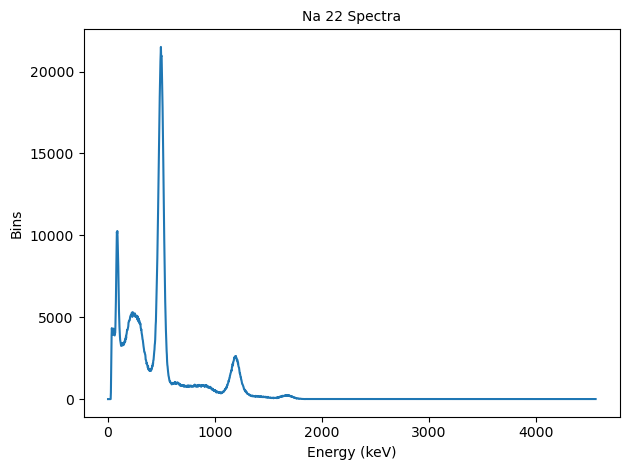

In [13]:
# This section is just me opening and plotting this raw data file. This is a gamma raw spectrum of a Na 22 isotope.

file_name = 'Na22_bumbia_text.txt'
df_Na = pd.read_csv(file_name, header = None)
Na_bins = df_Na.iloc[:, 0].astype(float)

bin_index_Na = []

for i in range(0, 2048):
    bin_index_Na.append(i)
    
# This part allows me to convert the data in my file corresponding to the x axis into the data for the y axis via a formula
# don't worry about it too much - it's just an annoying thing I had to do because of how this specific file was formatted
def na_to_energy():
    # Coefficients from the MCA_CAL data
    a = -1.421090E-014
    b = 2.227275
    c = 2.879121E-004
    
    energies_Na = []
    for i in bin_index_Na:
        # Calculate the energy
        energy = a*i**2 + b * i + c
        energies_Na.append(energy)
    
    return energies_Na

energy_keV_Na = na_to_energy()


plt.plot(energy_keV_Na, Na_bins, marker='', linestyle='-')
 
plt.xlabel('Energy (keV)', fontsize = 10)  
plt.ylabel('Bins', fontsize = 10)  
plt.title('Na 22 Spectra', fontsize = 10)  
plt.grid(False)  
plt.tight_layout()
plt.show()

## Example - Radioactive Spectrum Gaussian Curve Fit with Finding Peaks

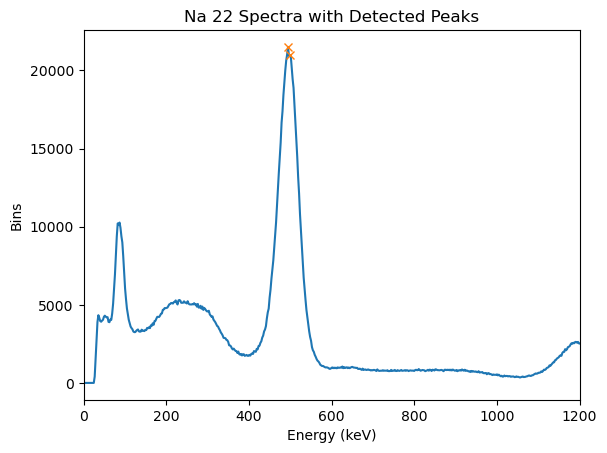

Peak 0: Energy = 494.4553379113997, Bin = 21506.0
Peak 1: Energy = 498.909887911387, Bin = 20982.0
Enter the index of the peak you are interested in: 0


C:\Users\17135\AppData\Local\Temp\ipykernel_33848\2504821412.py:37: RuntimeWarning:

invalid value encountered in sqrt



[[2.84664106e+02            nan            nan]
 [           nan 4.33720998e-01 1.74534661e-04]
 [           nan 1.74534661e-04 4.33721656e-01]]


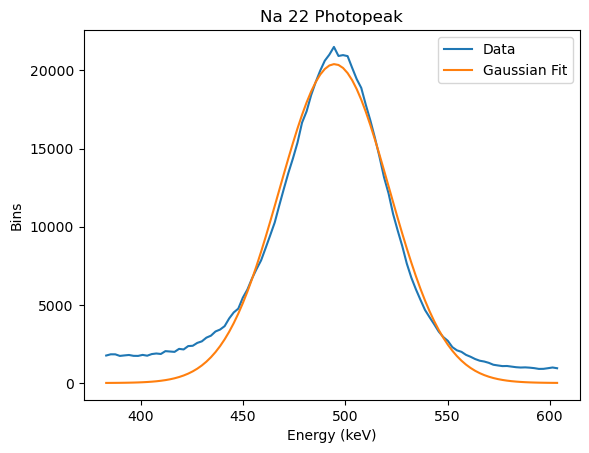

Fitted parameters: amplitude=20405.882080925745, center=494.7152619031436, width=26.92602481235799


In [14]:
# Identify peaks
peaks, properties = find_peaks(Na_bins, height=15000)  # Adjust height threshold as needed

# Plot data and peaks
plt.plot(energy_keV_Na, Na_bins)
plt.plot(np.array(energy_keV_Na)[peaks], Na_bins[peaks], "x")
plt.xlim(0, 1200)
plt.xlabel('Energy (keV)')
plt.ylabel('Bins')
plt.title('Na 22 Spectra with Detected Peaks')
plt.show()

# Print detected peaks for manual selection
for i, peak in enumerate(peaks):
    print(f"Peak {i}: Energy = {energy_keV_Na[peak]}, Bin = {Na_bins[peak]}")

# Choose the specific peak you are interested in (change the index to choose a different peak)
peak_index = int(input("Enter the index of the peak you are interested in: "))

# Isolate the data around the specified peak
range_width = 50  # Number of points to consider around the peak
start = max(0, peaks[peak_index] - range_width)
end = min(len(energy_keV_Na), peaks[peak_index] + range_width)
x_isolated = np.array(energy_keV_Na)[start:end]
y_isolated = Na_bins[start:end]

# Function to define a Gaussian
def gaussian(x, amp, cen, wid):
    return amp * np.exp(-(x - cen)**2 / (2 * wid**2))

# Initial guess for the Gaussian parameters
initial_guess = [max(y_isolated), x_isolated[np.argmax(y_isolated)], 10]

# Fit the Gaussian
popt, _ = curve_fit(gaussian, x_isolated, y_isolated, p0=initial_guess)

print(np.sqrt(_))
    
# Plot the result
plt.plot(x_isolated, y_isolated, label='Data')
plt.plot(x_isolated, gaussian(x_isolated, *popt), label='Gaussian Fit')
plt.xlabel('Energy (keV)')
plt.ylabel('Bins')
plt.title('Na 22 Photopeak')
plt.legend()
plt.show()

print(f"Fitted parameters: amplitude={popt[0]}, center={popt[1]}, width={popt[2]}")

## Example - Radioactive Spectrum Hyperbolic Tangent Curve Fit with Finding Peaks

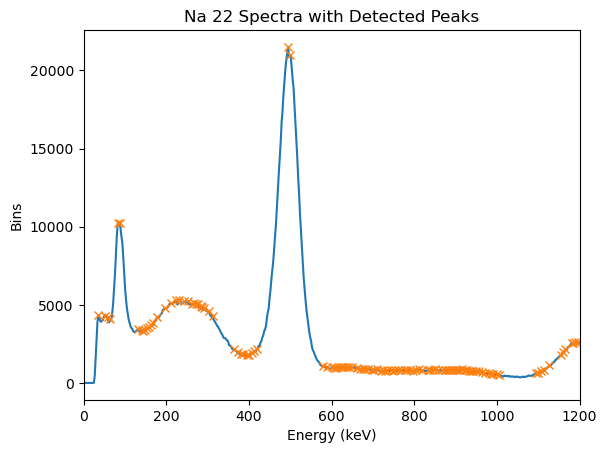

Peak 0: Energy = 35.63668791209636, Bin = 4335.0
Peak 1: Energy = 51.22761291209248, Bin = 4305.0
Peak 2: Energy = 57.9094379120904, Bin = 4209.0
Peak 3: Energy = 64.59126291208806, Bin = 4060.0
Peak 4: Energy = 82.40946291208056, Bin = 10211.0
Peak 5: Energy = 86.8640129120784, Bin = 10265.0
Peak 6: Energy = 131.40951291205053, Bin = 3422.0
Peak 7: Energy = 140.3186129120436, Bin = 3406.0
Peak 8: Energy = 144.77316291203994, Bin = 3351.0
Peak 9: Energy = 149.2277129120362, Bin = 3394.0
Peak 10: Energy = 153.68226291203231, Bin = 3523.0
Peak 11: Energy = 158.13681291202835, Bin = 3564.0
Peak 12: Energy = 162.59136291202427, Bin = 3689.0
Peak 13: Energy = 167.04591291202004, Bin = 3815.0
Peak 14: Energy = 178.18228791200906, Bin = 4230.0
Peak 15: Energy = 196.00048791198995, Bin = 4790.0
Peak 16: Energy = 211.59141291197173, Bin = 5116.0
Peak 17: Energy = 222.7277879119579, Bin = 5280.0
Peak 18: Energy = 231.6368879119463, Bin = 5307.0
Peak 19: Energy = 242.77326291193114, Bin = 5222.0


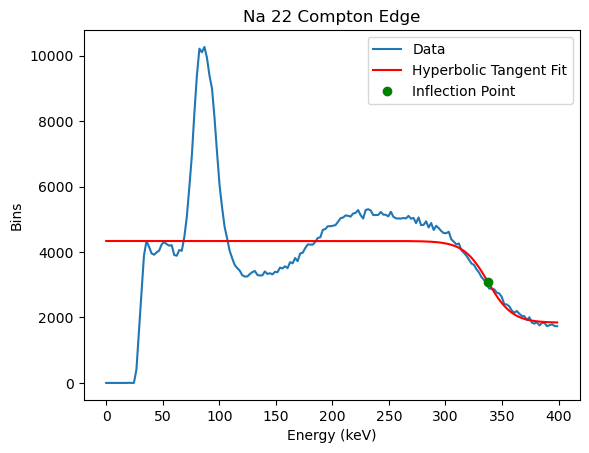

In [18]:
# Identify peaks
peaks, properties = find_peaks(Na_bins, height=500)  # Adjust height threshold as needed

# Plot data and peaks
plt.plot(energy_keV_Na, Na_bins)
plt.plot(np.array(energy_keV_Na)[peaks], Na_bins[peaks], "x")
plt.xlim(0, 1200)
plt.xlabel('Energy (keV)')
plt.ylabel('Bins')
plt.title('Na 22 Spectra with Detected Peaks')
plt.show()

# Print detected peaks for manual selection
for i, peak in enumerate(peaks):
    print(f"Peak {i}: Energy = {energy_keV_Na[peak]}, Bin = {Na_bins[peak]}")

# Choose the specific peak you are interested in (change the index to choose a different peak)
peak_index = int(input("Enter the index of the peak you are interested in: "))

# Isolate the data around the specified peak
range_width = 100
# Number of points to consider around the peak
start = max(0, peaks[peak_index] - range_width)
end = min(len(energy_keV_Na), peaks[peak_index] + range_width)
x_isolated = np.array(energy_keV_Na)[start:end]
y_isolated = Na_bins[start:end]

# Define the hyperbolic tangent function
def tanh_func(x, A, B, C, D):
    return A * np.tanh(B * (x - C)) + D

# Initial guess for the hyperbolic tangent parameters
A_guess = (np.max(y_isolated) - np.min(y_isolated)) / 2.5
B_guess = 1 / (x_isolated[-1] - x_isolated[0])
C_guess = np.mean(x_isolated)
D_guess = np.mean(y_isolated)
initial_guess = [A_guess, B_guess, C_guess, D_guess]

# Perform the curve fitting with increased maxfev
try:
    popt, pcov = curve_fit(tanh_func, x_isolated, y_isolated, p0=initial_guess, maxfev=5000)
    
    # Extract the fitted parameters
    A_fit, B_fit, C_fit, D_fit = popt

    # Print the fitted parameters
    print('The best fit parameters are:')
    print(f"Amplitude (A): {A_fit}")
    print(f"Frequency (B): {B_fit}")
    print(f"Center (C): {C_fit}")
    print(f"Vertical Shift (D): {D_fit}")

    # Print the errors for each parameter
    perr = np.sqrt(np.diag(pcov))
    print('The errors for each parameter are:')
    print(f"Error in Amplitude (A): {perr[0]}")
    print(f"Error in Frequency (B): {perr[1]}")
    print(f"Error in Center (C): {perr[2]}")
    print(f"Error in Vertical Shift (D): {perr[3]}")

    # Generate the fitted curve
    x_fit = np.linspace(min(x_isolated), max(x_isolated), 1000)
    y_fit = tanh_func(x_fit, *popt)

    # Find the inflection point (C parameter)
    inflection_point = C_fit

    # Print the x-coordinate of the inflection point
    print(f"Inflection Point: x = {inflection_point}")

    # Plot the original data, the fitted curve, and the inflection point
    plt.plot(x_isolated, y_isolated, '-', label='Data')
    plt.plot(x_fit, y_fit, 'r-', label='Hyperbolic Tangent Fit')
    plt.plot(inflection_point, tanh_func(inflection_point, *popt), 'go', label='Inflection Point')
    plt.title('Na 22 Compton Edge')
    plt.xlabel('Energy (keV)')
    plt.ylabel('Bins')
    plt.legend()
    plt.show()
except RuntimeError as e:
    print(f"An error occurred: {e}")
    
    
    # pick peak 14 here lol

## Example - Gaussian Curve Fit to Histogram

In [19]:
def read_file_with_pandas(file):
    # Read the file using pandas
    df = pd.read_csv(file, delim_whitespace=True, header=None)
    return df

file = 'SampleData_Summer2024.dat'
df = read_file_with_pandas(file)

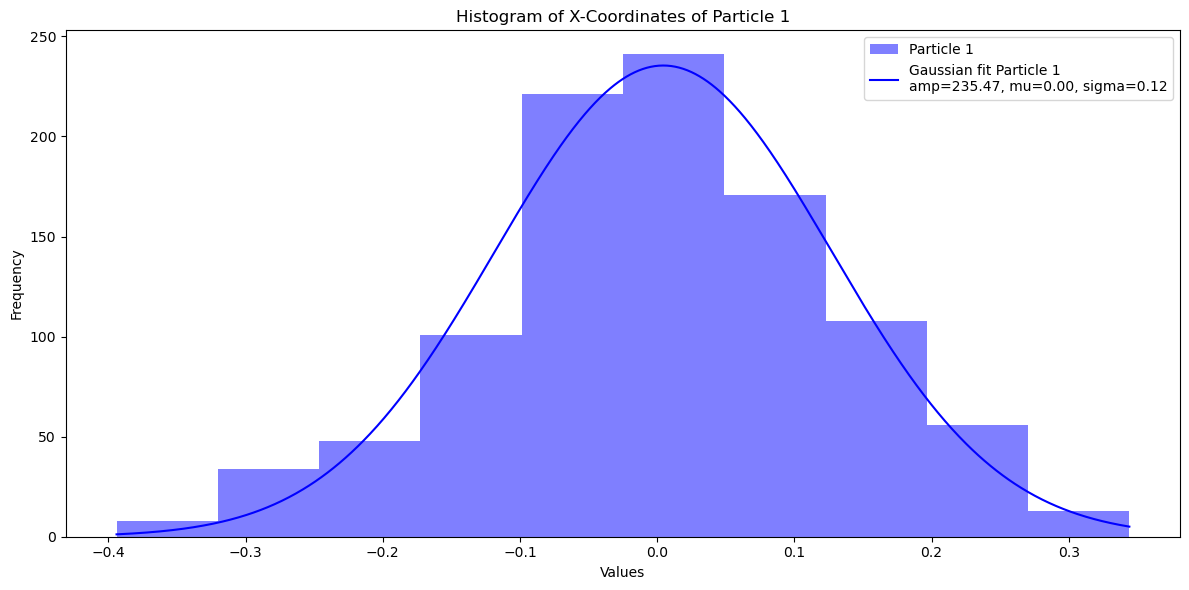

In [20]:
# Define the Gaussian function
def gaussian(x, amp, mu, sigma):
    return amp * np.exp(-((x - mu)**2) / (2 * sigma**2))

# Extract the relevant data column (I chose only one, but you can easily specify more)
column_to_plot = df.iloc[:, [1]]

# Plot histogram and fit Gaussian for column 1 (Particle 1)
plt.figure(figsize=(12, 6))

hist1, bins1, _ = plt.hist(column_to_plot.iloc[:, 0], bins=10, color='blue', alpha=0.5, label='Particle 1')

bin_centers1 = 0.5 * (bins1[1:] + bins1[:-1])

popt1, _ = curve_fit(gaussian, bin_centers1, hist1, p0=[np.max(hist1), np.mean(column_to_plot.iloc[:, 0]),
                                                        np.std(column_to_plot.iloc[:, 0])])

x_interval1 = np.linspace(bins1[0], bins1[-1], 1000)

plt.plot(x_interval1, gaussian(x_interval1, *popt1), color='blue', 
         label=f'Gaussian fit Particle 1\namp={popt1[0]:.2f}, mu={popt1[1]:.2f}, sigma={popt1[2]:.2f}')

plt.xlabel('Values')
plt.ylabel('Frequency')
plt.title('Histogram of X-Coordinates of Particle 1')
plt.legend()
plt.tight_layout()
plt.show()


## Example - Sinusoidal Fit

This example is from https://scipy-lectures.org/intro/scipy/auto_examples/plot_curve_fit.html

[3.05931973 1.45754553]


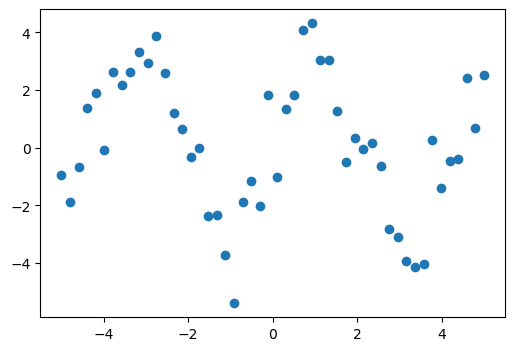

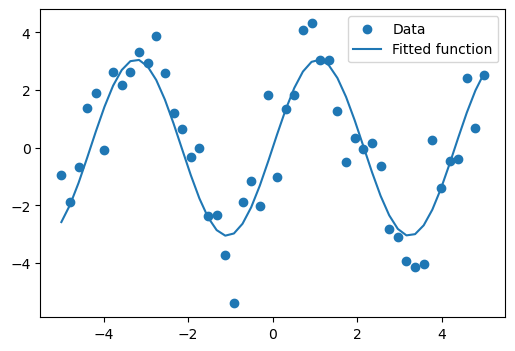

In [21]:
# Seed the random number generator for reproducibility
np.random.seed(0)

x_data = np.linspace(-5, 5, num=50)
y_data = 2.9 * np.sin(1.5 * x_data) + np.random.normal(size=50)

# And plot it
import matplotlib.pyplot as plt
plt.figure(figsize=(6, 4))
plt.scatter(x_data, y_data)

from scipy import optimize

def test_func(x, a, b):
    return a * np.sin(b * x)

params, params_covariance = optimize.curve_fit(test_func, x_data, y_data,
                                               p0=[2, 2])

print(params)

plt.figure(figsize=(6, 4))
plt.scatter(x_data, y_data, label='Data')
plt.plot(x_data, test_func(x_data, params[0], params[1]),
         label='Fitted function')

plt.legend(loc='best')

plt.show()

## Example - Image Processing + Linear Fit 

(768, 1024)


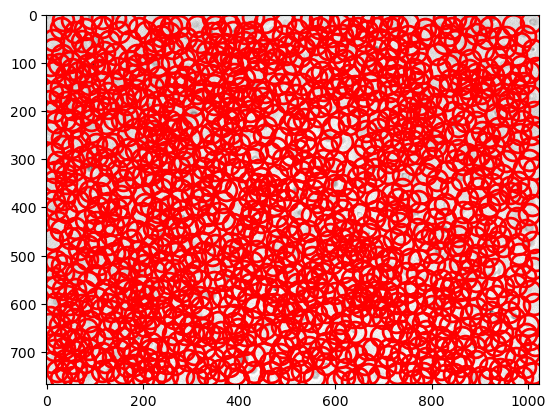

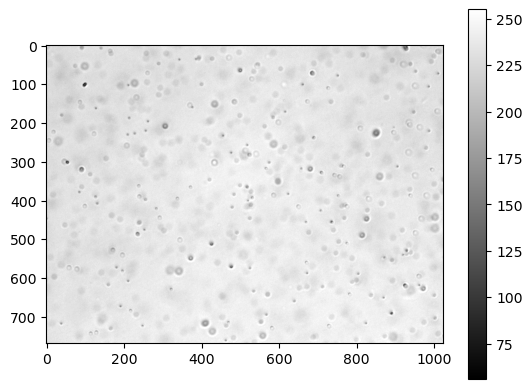

In [22]:
# Image processing - brownian motion 

# Define the gray function to extract the entire image (assuming grayscale)
@pims.pipeline
def gray(image):
    return image

# Load the TIFF stack
frames = gray(pims.open('real_data_2um.tif'))

# Verify the shape of frames
print(frames[0].shape)  # This should print (768, 1024)

f = tp.locate(frames[0], 13, invert=True)
# Annotate the first frame with detected features
tp.annotate(f, frames[0])

# Display the annotated image
plt.imshow(frames[0], cmap='gray')
plt.colorbar()
plt.show()


Frame 500: 428 trajectories present.


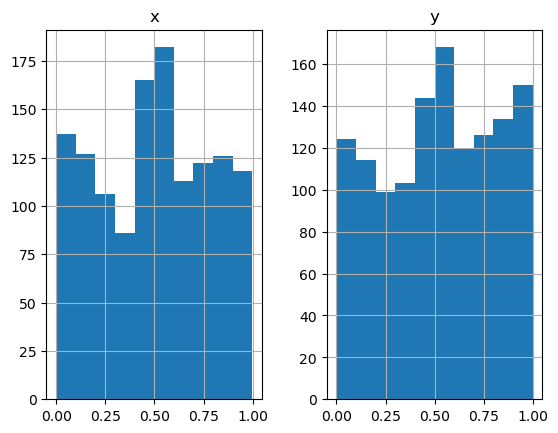

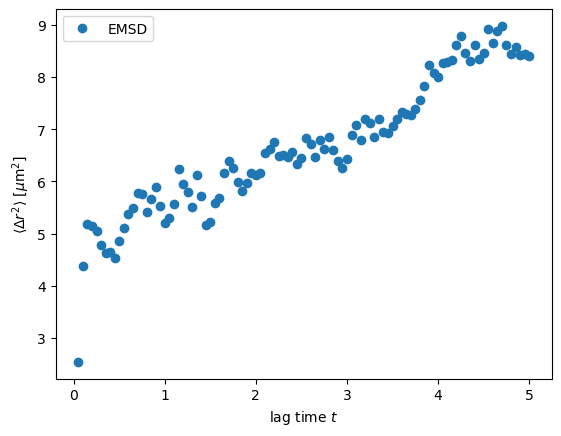

The slope of the linear fit is: 0.8412436853157195


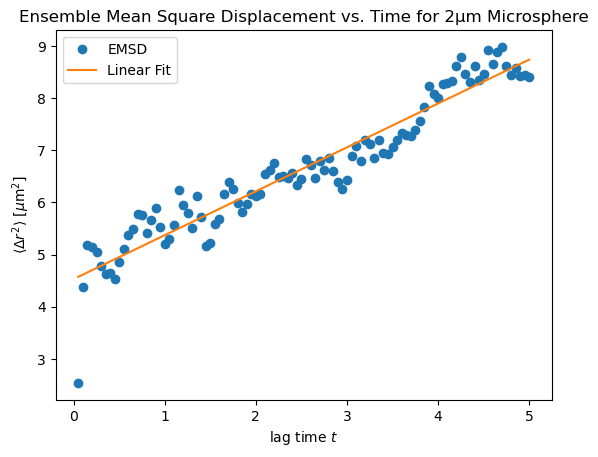

In [23]:
# data from a recording of brownian motion
tp.subpx_bias(f)

f = tp.batch(frames[:], 13, minmass=200, invert=True)

t = tp.link(f, 5, memory=3)

t1 = tp.filter_stubs(t, 25)

t2 = t1[((t1['mass'] > 50) & (t1['size'] < 2.6) &
         (t1['ecc'] < 0.3))]

d = tp.compute_drift(t2)

tm = tp.subtract_drift(t2.copy(), d)

em = tp.emsd(tm, 100/285., 20) 

# Plot the ensemble mean squared displacement (EMSD)
plt.figure()
plt.plot(em.index, em, 'o', label='EMSD')
plt.ylabel(r'$\langle \Delta r^2 \rangle$ [$\mu$m$^2$]')
plt.xlabel('lag time $t$')

plt.legend()
plt.show()

# Fit a linear model to the data
coefficients = np.polyfit(em.index, em, 1)
slope = coefficients[0]
linear_fit = np.polyval(coefficients, em.index)

# Print the slope of the linear fit
print(f"The slope of the linear fit is: {slope}")

# Plot the ensemble mean squared displacement (EMSD)
plt.figure()
plt.plot(em.index, em, 'o', label='EMSD')

# Plot the linear fit
plt.plot(em.index, linear_fit, '-', label='Linear Fit')

plt.ylabel(r'$\langle \Delta r^2 \rangle$ [$\mu$m$^2$]')
plt.xlabel('lag time $t$')
plt.title('Ensemble Mean Square Displacement vs. Time for 2μm Microsphere' )
plt.legend()
plt.show()

## Example - Linear Fit Using Photoelectric Effect Data

The slope of the linear fit is: 1.4962318860750698e-14


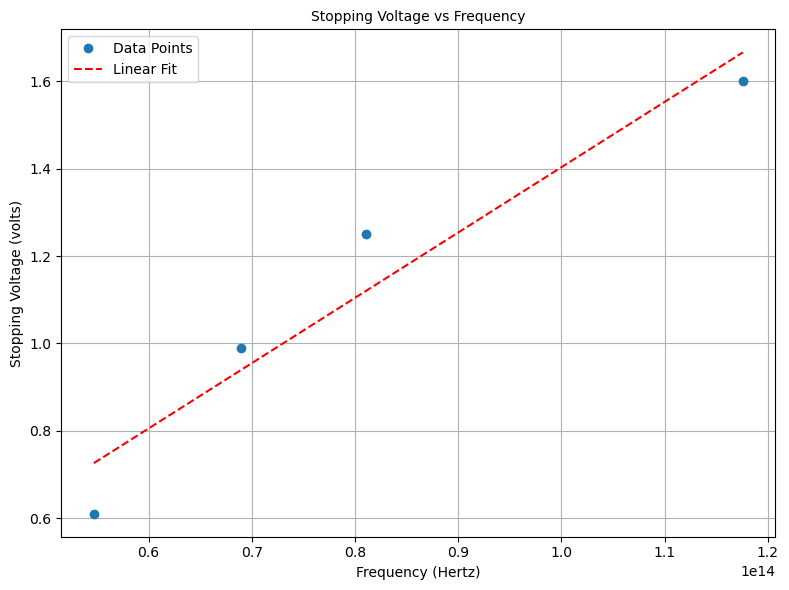

In [24]:
# Data
frequency_sorted = [
    54706652919708.03,  # Corresponding to '548 nm'
    68917806436781.61,  # Corresponding to '431-440 nm'
    81024988648648.65,  # Corresponding to '365-375 nm'
    117565669803921.58  # Corresponding to '249-259 nm'
]
stop_volt = [0.61, 0.99, 1.25, 1.6]
title = 'Stopping Voltage vs Frequency'

# Perform linear fit
coefficients = np.polyfit(frequency_sorted, stop_volt, 1)
linear_fit = np.poly1d(coefficients)

# Generate values for the fit line
frequency_fit = np.linspace(min(frequency_sorted), max(frequency_sorted), 500)
stop_volt_fit = linear_fit(frequency_fit)

# The slope is the first coefficient
slope = coefficients[0]

print(f"The slope of the linear fit is: {slope}")

# Plotting
plt.figure(figsize=(8, 6))
plt.plot(frequency_sorted, stop_volt, marker='o', linestyle='', label='Data Points')
plt.plot(frequency_fit, stop_volt_fit, color='red', linestyle='--', label='Linear Fit')
plt.xlabel('Frequency (Hertz)', fontsize=10)
plt.ylabel('Stopping Voltage (volts)', fontsize=10)
plt.title(title, fontsize=10)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()